#Credit Risk Prediction Using Synthetic Data (CTGAN)

Credit risk prediction is essential for financial institutions to minimize loan defaults.

Traditional datasets are often imbalanced, with fewer fully paid loans (minority class) compared to defaults.

This study leverages synthetic data generation using CTGAN to augment minority class data and improve model performance.

#Dataset
I have used the ***"Credit Risk Dataset"*** from kaggle

link: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

Dataset contains **~33,000 loan records** with features including:

`person_age`, `person_income`, `loan_amnt`, `loan_int_rate`

`person_emp_length`, `loan_intent`, `loan_grade`

`person_home_ownership`, `cb_person_default_on_file`, `cb_person_cred_hist_length`, `loan_percent_income`

Our Target variable: `loan_status` were

0 = Charged Off or defaults

1 = Fully Paid

## Install and import libraries


In [81]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost sdv -q

In [44]:
!pip install --upgrade sdv -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from sdv.single_table import CTGANSynthesizer
from sklearn.decomposition import PCA
import pickle, warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)


## Loading Dataset

In [45]:
df = pd.read_csv("/content/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [46]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [47]:
print(df.columns)

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


The target for credit risk prediction is **loan_status**.

## Handling Missing Values

In [48]:
# Check missing values
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


so here we can infer that,
- person_emp_length - 895 implies  ~9–10% missing → can impute
- loan_int_rate - 3116 implies Very high missing →  dropping or imputing carefully
- others have zero implying no missing value

In [50]:
# Imputing numerical columns
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

# Checking missing values again
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


Median is robust to outliers, so it’s safer than mean for financial data thus used median

Now we can see that missing values are handled,

## Exploratory Data Analysis

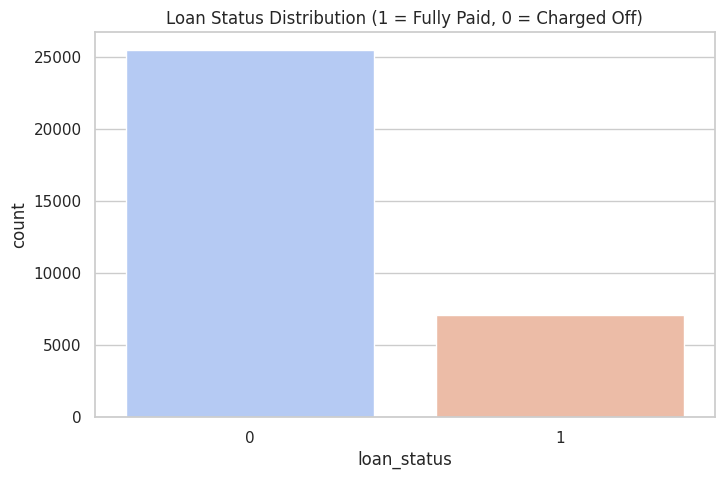

Target value counts:
 loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


In [51]:
# Target distribution
sns.countplot(x='loan_status', data=df, palette='coolwarm')
plt.title("Loan Status Distribution (1 = Fully Paid, 0 = Charged Off)")
plt.show()

print("Target value counts:\n", df['loan_status'].value_counts(normalize=True))


### **Target Distribution (loan_status)**

Majority of loans are defaults (78%), fully paid loans are 22%.

Dataset is **imbalanced**, so models need techniques to **handle minority class**.

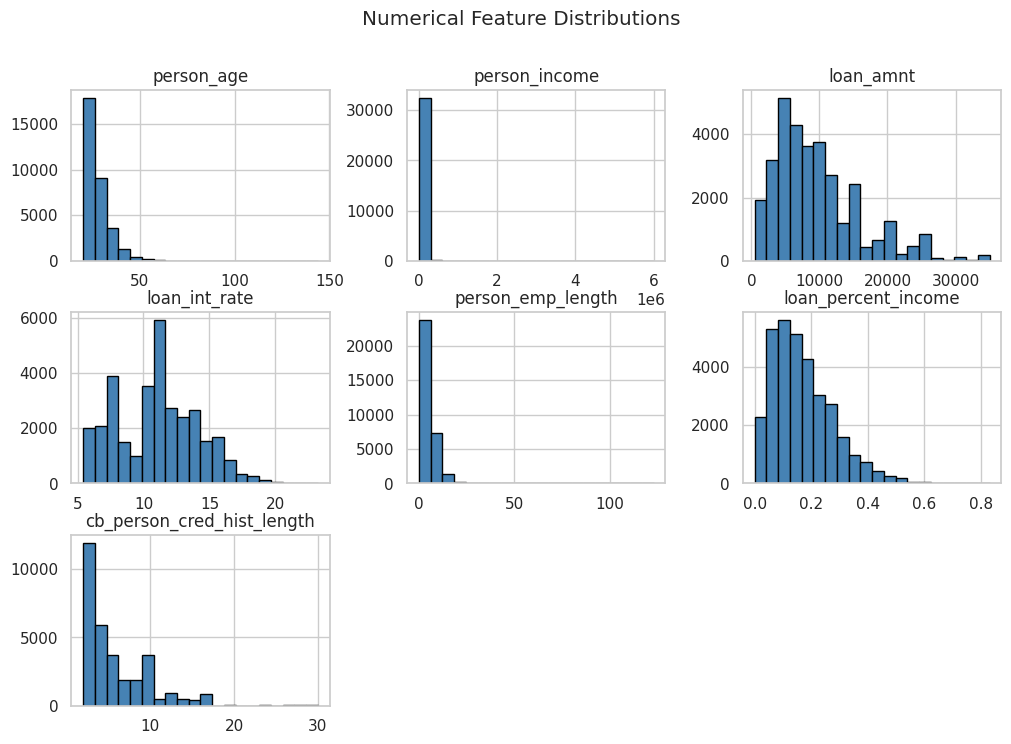

In [59]:
# Numerical feature distributions
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'person_emp_length', 'loan_percent_income', 'cb_person_cred_hist_length']
df[num_cols].hist(figsize=(12,8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Numerical Feature Distributions")
plt.show()


### **Numerical Feature Distributions**

**loan_amnt** and **loan_int_rate** are **right-skewed**, with some very high loans/rates.

Most applicants are **25–60 years old**, median age *~40.*

*Income* distribution is **skewed**: most earn *30k–70k.*

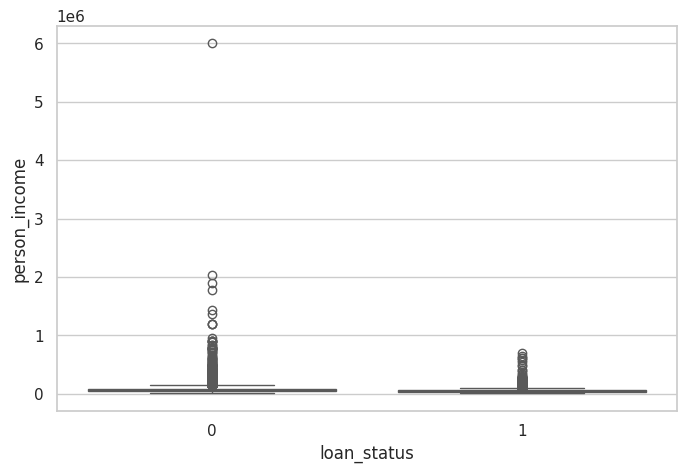

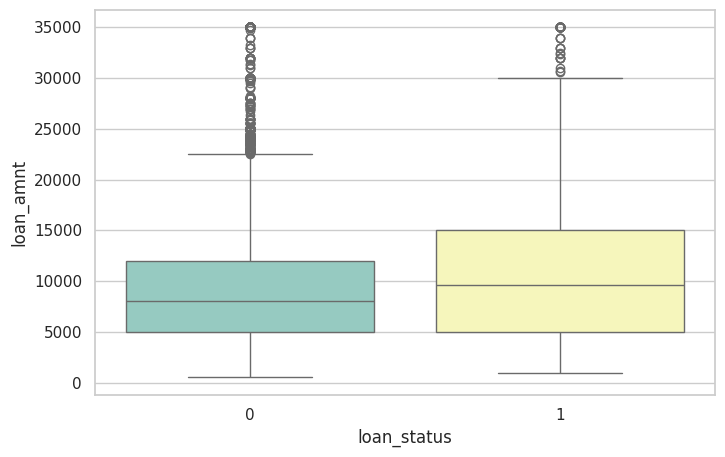

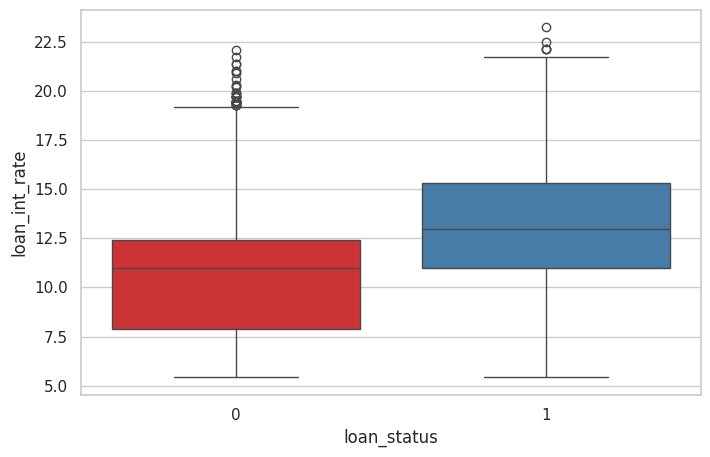

In [53]:
# Boxplots: relationship between numeric features and target
sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2'); plt.show()
sns.boxplot(x='loan_status', y='loan_amnt', data=df, palette='Set3'); plt.show()
sns.boxplot(x='loan_status', y='loan_int_rate', data=df, palette='Set1'); plt.show()

### Boxplot Insights (loan_status vs Numerical Features)

1. **person_income vs loan_status**

- Higher-income applicants tend to have fully paid loans.

- Lower-income applicants show a slightly higher probability of default.

- Income alone is not a perfect predictor, but contributes to risk assessment.

2. **loan_amnt vs loan_status**

- Charged-off loans tend to have higher loan amounts.

- Larger loans are associated with a higher probability of default → strong predictor of credit risk.

3. **loan_int_rate vs loan_status**

- Higher interest rates are more common for defaults.

- Loans with higher interest rates carry higher risk of default → another important predictor.

**Overall Insight:**

Higher loan amounts + higher interest rates + lower incomes are linked to higher default risk.

No single feature perfectly separates classes → multivariate modeling needed.

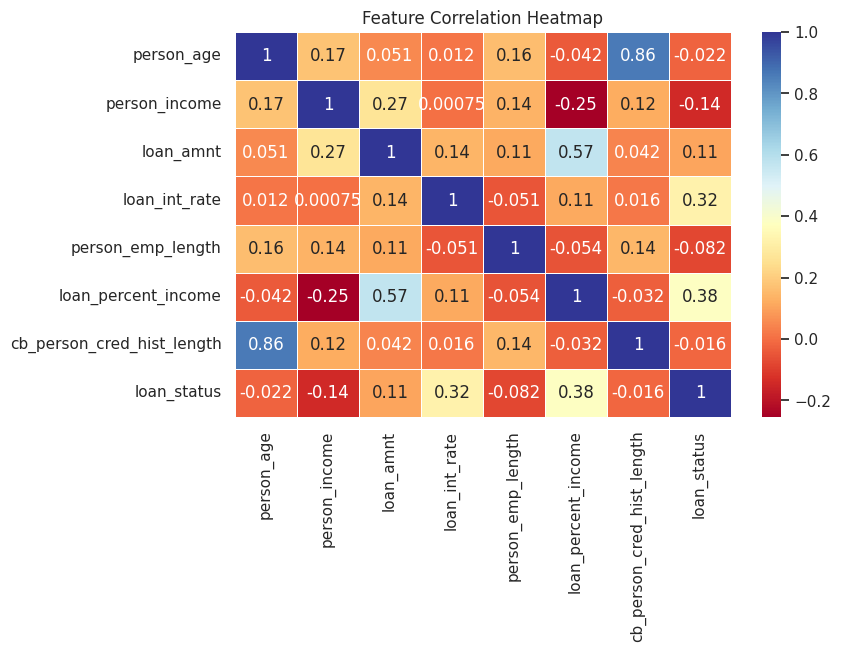

In [54]:
# Correlation heatmap
corr = df[num_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', linewidths=.5)
plt.title("Feature Correlation Heatmap")
plt.show()


### Heatmap
- **loan_percent_income** and **loan_int_rate** have the **strongest positive** linear correlation with loan_status (default). Higher values in these features mean higher default risk.
- **person_income** has a **weak negative** correlation with loan_status.
- **person_age** and **cb_person_cred_hist_length** are **strongly correlated** with each other.

These insights highlight the most important numerical features related to credit risk in this dataset based on linear relationships.

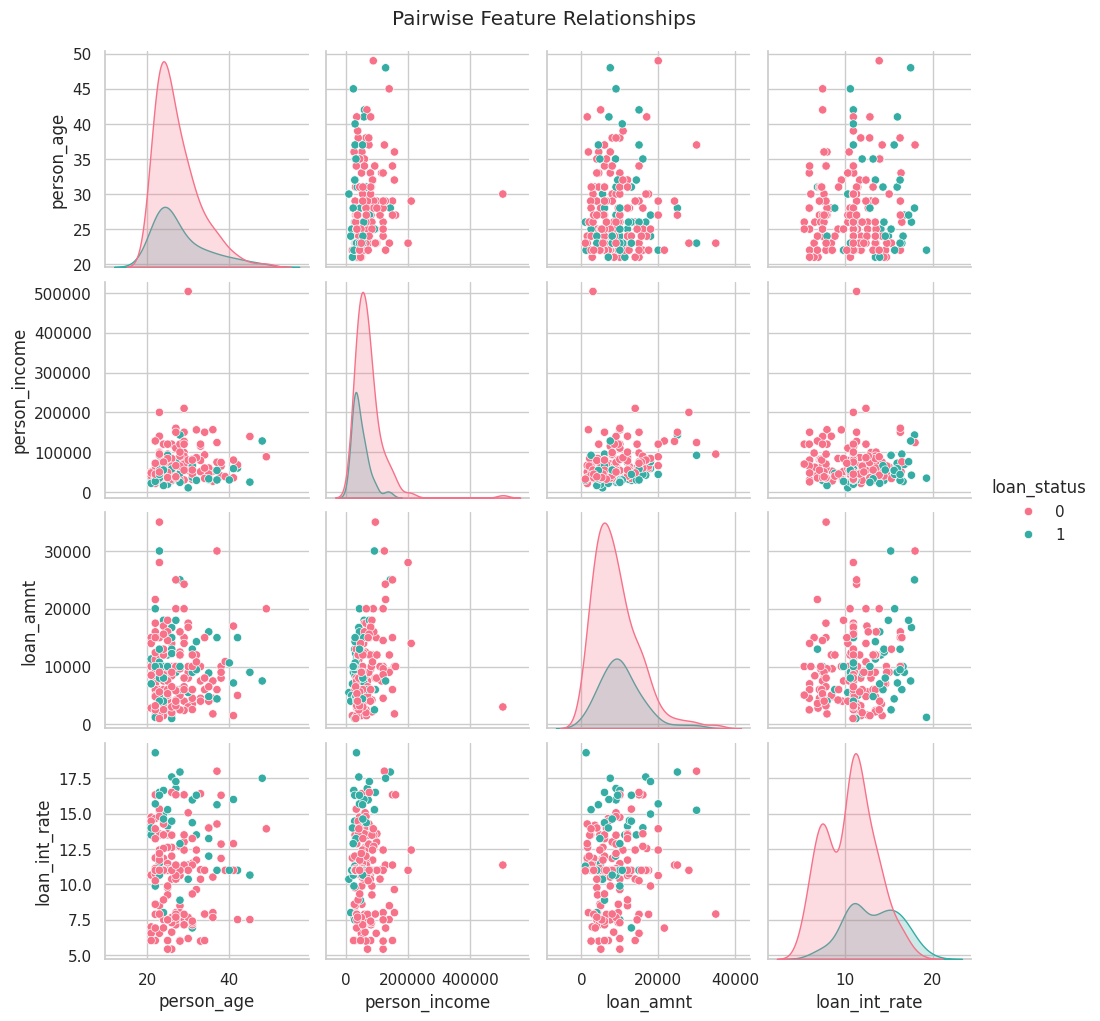

In [55]:
# Pairplot (subset for speed)
sns.pairplot(df[['person_age','person_income','loan_amnt','loan_int_rate','loan_status']].sample(200),
             hue='loan_status', palette='husl')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

### Pairplot
It visually confirms that features like **loan amount** and **interest rate** are important in distinguishing between **fully paid** and **charged-off loans**, as the points for these two groups tend to **occupy different regions** in the scatter plots involving these features.

## Synthetic Data Generation using CTGAN

To balance the **minority class (loan_status = 1)** in the dataset.

Since dataset has imbalanced classes **(~22% fully paid)**, generating **synthetic “fully paid” loans** will help the model learn better.

In [69]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import pandas as pd

# Selecting only the minority class
minority_df = df[df['loan_status'] == 1]


In [70]:
# Creating metadata object
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=minority_df)

In [72]:
#Intializing
ctgan = CTGANSynthesizer(metadata, epochs=50)

#Fit and sample synthetic data
ctgan.fit(minority_df)

In [79]:
# Generating 1000 synthetic fully paid loans
synthetic_minority = ctgan.sample(1000)

# Adding target column
synthetic_minority['loan_status'] = 1

# Combining with original dataset
augmented_df = pd.concat([df, synthetic_minority], ignore_index=True)

# Checking class distribution
print(augmented_df['loan_status'].value_counts())


loan_status
0    25473
1     8108
Name: count, dtype: int64


In [80]:
# Generating more synthetic rows, (12,000 first)
synthetic_more = ctgan.sample(12000)

# Adding  target column
synthetic_more['loan_status'] = 1

# Combining with current augmented dataset
augmented_df = pd.concat([augmented_df, synthetic_more], ignore_index=True)

# Checking new class distribution
print(augmented_df['loan_status'].value_counts())


loan_status
0    25473
1    20108
Name: count, dtype: int64


### Insight:

The minority class (1 = fully paid) has been heavily augmented with synthetic data.

The dataset is now close to **balanced**, which will help the model learn both classes effectively.

## Modeling Credit Risk with XGBoost – Real vs Augmented Data

### Encode categorical features
The dataset was encoded and split into train/test sets for modeling.

In [82]:
from sklearn.preprocessing import LabelEncoder

# Function to encode categorical columns
def encode_dataframe(df):
    df_enc = df.copy()
    for col in df_enc.select_dtypes(include='object').columns:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
    return df_enc

# Encoding the augmented dataset
aug_enc = encode_dataframe(augmented_df)

# Encoding original dataset for comparison
df_enc = encode_dataframe(df)


In [83]:
# Dropping target from features
X_real = df_enc.drop('loan_status', axis=1)
y_real = df_enc['loan_status']

X_aug = aug_enc.drop('loan_status', axis=1)
y_aug = aug_enc['loan_status']

### Train/Test Split

In [84]:
from sklearn.model_selection import train_test_split

# Real data
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_real, y_real, test_size=0.3, random_state=42, stratify=y_real)

# Augmented data
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug)


### Training XGBoost models

In [85]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Function to train & evaluate
def train_evaluate(X_train, X_test, y_train, y_test, label):
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"\n {label}")
    print(classification_report(y_test, preds))
    print("AUC:", round(auc,3))
    return model, auc

# Real data model
real_model, auc_real = train_evaluate(Xr_tr, Xr_te, yr_tr, yr_te, "Real Data Model")

# Augmented data model
aug_model, auc_aug = train_evaluate(Xa_tr, Xa_te, ya_tr, ya_te, "Augmented Data Model")



 Real Data Model
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.96      0.74      0.84      2133

    accuracy                           0.94      9775
   macro avg       0.95      0.87      0.90      9775
weighted avg       0.94      0.94      0.93      9775

AUC: 0.948

 Augmented Data Model
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      7642
           1       0.98      0.91      0.94      6033

    accuracy                           0.95     13675
   macro avg       0.95      0.95      0.95     13675
weighted avg       0.95      0.95      0.95     13675

AUC: 0.98


### ROC Curve Comparison

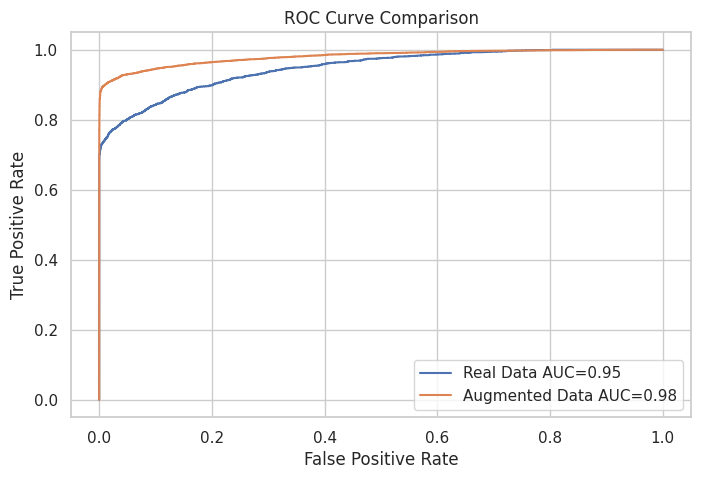

In [86]:
fpr_r, tpr_r, _ = roc_curve(yr_te, real_model.predict_proba(Xr_te)[:,1])
fpr_a, tpr_a, _ = roc_curve(ya_te, aug_model.predict_proba(Xa_te)[:,1])

plt.plot(fpr_r, tpr_r, label=f"Real Data AUC={auc_real:.2f}")
plt.plot(fpr_a, tpr_a, label=f"Augmented Data AUC={auc_aug:.2f}")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.show()


### **Key Insight:**
1. **Real Data Model**

- Accuracy: 94%

- AUC: 0.948

- Recall for minority class (1 = fully paid) is 0.74, indicating the model misses ~26% of fully paid loans.

- Precision is high, but the model struggles with the underrepresented class due to imbalance.

2. **Augmented Data Model**

- Accuracy: 95%

- AUC: 0.98

- Recall for minority class improves to 0.91, meaning the model now correctly identifies most fully paid loans.

- Both precision and recall are high → balanced performance across classes.



### **Key Insight**

Synthetic data generation with CTGAN significantly improved the model’s ability to detect the minority class.

ROC-AUC increased from 0.948 → 0.98, showing better discrimination between defaults and fully paid loans.

Augmentation reduces bias caused by class imbalance, leading to more reliable credit-risk predictions.



In [88]:
#Saving the augmented model
import pickle
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pickle.dump(aug_model, open("credit_model.pkl", "wb"))
augmented_df.to_csv("augmented_credit_data.csv", index=False)
print("Model and augmented data saved for Streamlit.")

Model and augmented data saved for Streamlit.


## PCA Visualization: Real vs Synthetic

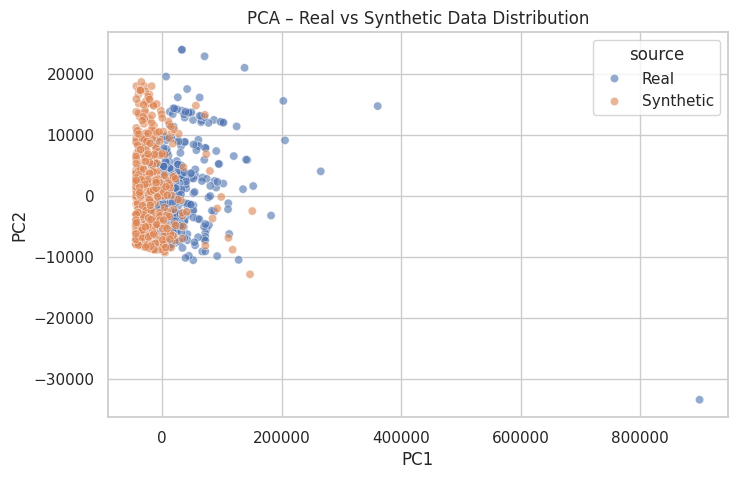

In [90]:
#Taking samples for clarity
real_sample = df.sample(500, random_state=42)
synthetic_sample = augmented_df[~augmented_df.index.isin(df.index)].sample(500, random_state=42)

# Marking source
real_sample['source'] = 'Real'
synthetic_sample['source'] = 'Synthetic'

combined = pd.concat([real_sample, synthetic_sample], ignore_index=True)

# Encoding categorical features
def encode_for_pca(df):
    df_enc = df.copy()
    for c in df_enc.select_dtypes('object'):
        df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))
    return df_enc

encoded = encode_for_pca(combined.drop('source', axis=1))

# Applying PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(encoded)
combined[['PC1', 'PC2']] = pcs

# Plot
sns.scatterplot(data=combined, x='PC1', y='PC2', hue='source', alpha=0.6)
plt.title("PCA – Real vs Synthetic Data Distribution")
plt.show()

### Insights
The PCA plot shows **good overlap between** the real and synthetic data, indicating that **CTGAN generated realistic samples** that maintain the original data distribution.

Benefit: Synthetic data improves minority class learning without compromising data distribution.

## StreamLit

In [100]:
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the saved model
loaded_model = pickle.load(open("credit_model.pkl", "rb"))

# Create a sample input DataFrame for prediction
# Make sure the column names and order match the training data
sample_input = pd.DataFrame({
    'person_age': [30],
    'person_income': [60000],
    'person_home_ownership': ['RENT'],
    'person_emp_length': [5.0],
    'loan_intent': ['PERSONAL'],
    'loan_grade': ['B'],
    'loan_amnt': [15000],
    'loan_int_rate': [12.5],
    'loan_percent_income': [0.25],
    'cb_person_default_on_file': ['N'],
    'cb_person_cred_hist_length': [7]
})


def encode_dataframe_for_prediction(df_to_encode, original_df_for_fit):
    df_enc = df_to_encode.copy()
    for col in df_enc.select_dtypes(include='object').columns:
        le = LabelEncoder()

        le.fit(original_df_for_fit[col].astype(str).unique())
        df_enc[col] = le.transform(df_enc[col].astype(str))
    return df_enc

# Load the original or augmented data to fit the LabelEncoders
# using the augmented_df as it includes the synthetic data categories
augmented_df_loaded = pd.read_csv("augmented_credit_data.csv")


# Encoding the sample input data
encoded_sample_input = encode_dataframe_for_prediction(sample_input, augmented_df_loaded)

# prediction
prediction = loaded_model.predict(encoded_sample_input)

result = "High Risk (Likely to Default)" if prediction[0] == 1 else "Low Risk (Likely to Repay)"

print(f"The predicted loan status is: {result}")

The predicted loan status is: Low Risk (Likely to Repay)


In [102]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load model and data
model = pickle.load(open("credit_model.pkl", "rb"))
augmented_df = pd.read_csv("augmented_credit_data.csv")

# Prepare label encoders using the augmented dataset
label_encoders = {}
categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in categorical_columns:
    le = LabelEncoder()
    le.fit(augmented_df[col])
    label_encoders[col] = le

st.title("Credit Risk Prediction App")

st.sidebar.header("Enter Applicant Information")

# Sidebar inputs
age = st.sidebar.slider("Age", 18, 80, 35)
income = st.sidebar.number_input("Annual Income ($)", 10000, 200000, 50000)
emp_length = st.sidebar.slider("Employment Length (Years)", 0, 40, 5)
home_ownership = st.sidebar.selectbox("Home Ownership", label_encoders['person_home_ownership'].classes_)
loan_intent = st.sidebar.selectbox("Loan Intent", label_encoders['loan_intent'].classes_)
loan_grade = st.sidebar.selectbox("Loan Grade", label_encoders['loan_grade'].classes_)
loan_amnt = st.sidebar.number_input("Loan Amount", 500, 50000, 10000)
interest_rate = st.sidebar.slider("Loan Interest Rate (%)", 2.0, 30.0, 10.0)
percent_income = st.sidebar.number_input("Loan % of Income", 0.0, 1.0, 0.2)
default_on_file = st.sidebar.selectbox("Default on File", label_encoders['cb_person_default_on_file'].classes_)
cred_hist_len = st.sidebar.slider("Credit History Length", 0, 40, 5)

# Combine inputs
input_data = pd.DataFrame({
    'person_age': [age],
    'person_income': [income],
    'person_home_ownership': [home_ownership],
    'person_emp_length': [emp_length],
    'loan_intent': [loan_intent],
    'loan_grade': [loan_grade],
    'loan_amnt': [loan_amnt],
    'loan_int_rate': [interest_rate],
    'loan_percent_income': [percent_income],
    'cb_person_default_on_file': [default_on_file],
    'cb_person_cred_hist_length': [cred_hist_len]
})

# Apply label encoding
for col in categorical_columns:
    input_data[col] = label_encoders[col].transform(input_data[col])

# Prediction
if st.button("Predict Loan Status"):
    prediction = model.predict(input_data)[0]
    result = "High Risk (Likely to Default)" if prediction == 1 else "Low Risk (Likely to Repay)"
    st.subheader(f"Prediction: {result}")

# Visualization
st.subheader("Data Overview & Insights")
st.write("Sample of augmented dataset:")
st.dataframe(augmented_df.head())

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=augmented_df, x="loan_status", palette="coolwarm", ax=ax)
st.pyplot(fig)


Overwriting app.py
